# Federated learning: ECI 2026 Project

This is the [final optional project](http://ichatz.me/Site/FederatedLearningECI2026Project) for the course Federated Learning taught by [Ioannis Chatzigiannakis](http://ichatz.me/Site/Home) at the Escuelas de Ciencias Informáticas in July 2026. 

The course itself followed the idea of dataset descentralization to perform Machine Learning to avoid providing sensitive (raw) data to privately-owned servers, during the course we also tackled the problems regarding non-IIDness, adversarial clients, privacy & security. 

It was overall a fantastic course that really sparked my interest in what is usually an underlooked aspect of digitalization, how we protect our data & the trust we place in big corporations.

With that being said, the objective here is to simulate a small federated learning scenario


## SETUP

First we need to install Tensorflow (and it's datasets) & MatPlotLib 

In [1]:
!pip install -q matplotlib
!pip install -q tensorflow tensorflow_probability[tf]
!pip install -q numpy
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install -q scikit-learn

Then we import it

In [2]:
import matplotlib.pyplot as plt
import torchvision
import tensorflow_probability as tfp
import tensorflow as tf
import numpy as np
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy

I0000 00:00:1786318274.642751    8268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786318274.645907    8268 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786318274.973907    8268 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786318276.366296    8268 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Dataset

I'm going to be using [CIFAR10](https://www.tensorflow.org/datasets/catalog/cifar10?hl=es), a dataset containing 60000 32x32 colour images uniformly distributed amongst 10 classes. 

We want an equal label-wise distribution using a **60/10/30** split for training, validation & test, for that reason we must stratify the split using the labels 

> The dataset itself is pre-split so we need to recombine it and then split it

In [5]:
train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=True)
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=True)

train_labels = torch.from_numpy(np.array(train_data.targets)).long()
test_labels = torch.from_numpy(np.array(test_data.targets)).long()

train_images = torch.from_numpy(train_data.data)
test_images = torch.from_numpy(test_data.data)

train_images_normalized = (train_images).float() / 255.0   
train_images_normalized = train_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

test_images_normalized = (test_images).float() / 255.0   
test_images_normalized = test_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

train_labels = (train_labels).long()   
test_labels = (test_labels).long()     

images = torch.cat([train_images_normalized, test_images_normalized], dim=0)
labels = torch.cat([train_labels, test_labels], dim=0)

# First we take the 60% split
X_train, X_temp, Y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.40,      
    random_state=42,
    stratify=labels   
)

# Then we split the remaining 40% of the dataset into 10/30
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.75,      
    random_state=42,
    stratify=y_temp      
)

train_data = TensorDataset(X_train, Y_train)
val_data   = TensorDataset(X_val, Y_val)
test_data  = TensorDataset(X_test, Y_test)

print(train_data.tensors[0].shape)  
print(train_data.tensors[1].shape)


torch.Size([36000, 3, 32, 32])
torch.Size([36000])


### Dataset Analysis

Now we can plot and visualize some of the data distribution, in particular we can see

1.  Histogram of the classes
2.  Few samples

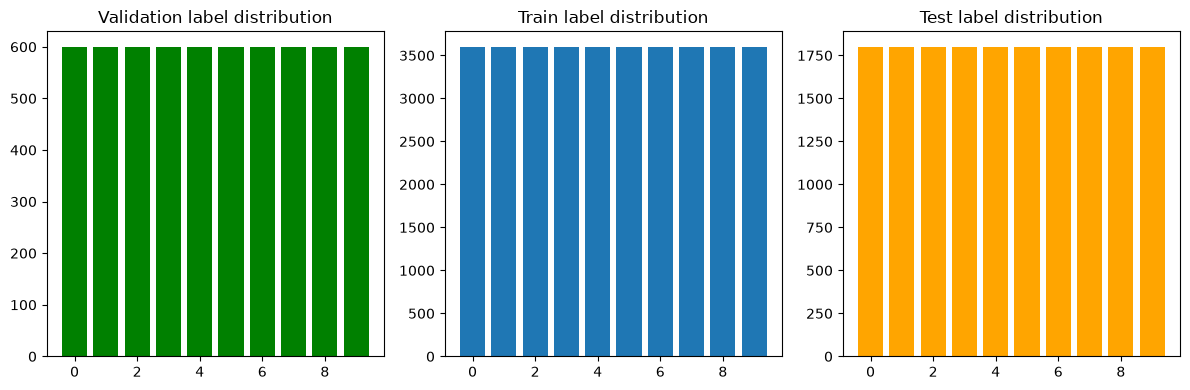

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(np.unique_counts(Y_val).values, np.unique_counts(Y_val).counts, color="green")
axes[0].set_title("Validation label distribution")
axes[1].bar(np.unique_counts(Y_train).values, np.unique_counts(Y_train).counts)
axes[1].set_title("Train label distribution")
axes[2].bar(np.unique_counts(Y_test).values, np.unique_counts(Y_test).counts, color="orange")
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

As we can see there is no quantity skewness because all labels have exactly 6000 samples (although we will split it into non-IID scenarios).

Let's visualize some samples of the images to get a general idea of what they look like

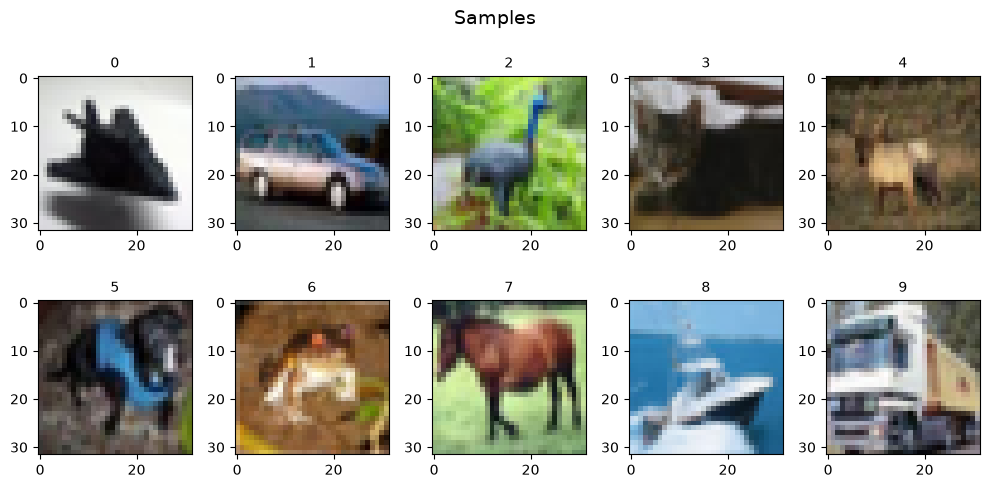

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

axes_flat = axes.flatten()

for i in range(10):
    j = 0
    while train_labels[j] != i:
        j += 1
        
    if j < len(train_labels):
        ax = axes_flat[i]
        ax.imshow(train_images[j])
        ax.set_title(f"{train_labels[j]}", fontsize=10)

plt.suptitle("Samples", fontsize=14)
plt.tight_layout()
plt.show()

## Centralized Baseline

As we attempt to showcase the effectiveness of Federated Learning (& the challenges it poses) we need a baseline for comparison, in this case the obvious thing to do is to have a standard centralized model. 

### Model construction

Now we will build a 2D Sequential Convolutional Neural Network 

<details>
<summary><b>Sources</b></summary>

* Model:    
    -   [Sequential CNNs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html)
* Layers: 
    -   [Conv2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
    -   [AveragePooling2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.AvgPool2d.html#torch.nn.AvgPool2d)
    -   [Flatten](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Flatten.html#torch.nn.Flatten)
    -   [Linear (Dense)](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Linear.html#torch.nn.Linear)
    -   [Dropout](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html#torch.nn.Dropout)
*   Activation Functions:
    -   [softmax](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Softmax.html)
    -   [relu](https://docs.pytorch.org/docs/2.13/generated/torch.nn.ReLU.html)

</details>

We define our model's layers, looking at the dataset's shape

In [6]:
print(train_data.tensors[0].shape) #X shape
print(train_data.tensors[1].shape) #Y shape

torch.Size([36000, 3, 32, 32])
torch.Size([36000])


In [37]:
initial_model = nn.Sequential(

    #Feature Extraction
    nn.Conv2d(3, 8, (7,7), padding="same", stride=1), #3 channels (image has color, otherwise it'd be 1 channel?)
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(8, 16, (5,5), padding="same", stride=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(16, 32, (3,3), padding="same", stride=1),
    nn.ReLU(),

    #Classifier
    nn.Flatten(), 
    nn.Dropout(p=0.3),
    nn.Linear(2048, 128), #value 2048 is because of 32x32x32x3 / 2 / 2 
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.Linear(64,10),
    nn.LogSoftmax(dim=1)
)

### Train & Test steps

Now with our model properly defined we have to define what training and testing means

Training will take each (image,label) tuple and make the model predict the label, after that we calculate the loss with the truth and then perform backpropagation.

Testing will also take (image, label) tuples, predict a label, validate the result and finally calculate the overall guess rate 

In [39]:


def train(model, optimizer, dataLoader, loss_fn):
    model.train()
    total_loss = 0
    dataset_size = len(dataLoader.dataset)
    for (X, y) in (dataLoader):

        # Predict then calculate loss
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        #Calculate loss 
        total_loss += loss.item() * X.size(0)

    avg_loss = total_loss/dataset_size

    return model, avg_loss

def test(model, dataLoader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    dataset_size = len(dataLoader.dataset)

    #Using .no_grad makes sure the model doesn't actually learn from the test 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            #Calculate loss 
            loss = loss_fn(pred, y)
            total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / dataset_size
    accuracy = correct / dataset_size

    return (accuracy, avg_loss)



### Model Training 

With all pieces in place we can now perform an optimized training routine that will track accuracy over the validation set and restore the best weights if no improvements are seen after 3 epochs, we will utilize 2 optimizers and compare the results 

In [40]:
def run_model(model, optimizer, epochs, train_dataloader, val_dataloader):

    best_model = copy.deepcopy(model)
    best_model_accuracy = 0
    stall_count = 0
    train_accAndloss_arr = []
    val_accAndloss_arr = []

    for t in range(epochs):
        model, current_loss = train(model, optimizer, train_dataloader, nn.NLLLoss())  #We train the model
        (model_accuracy, current_loss) = test(model, val_dataloader, nn.NLLLoss())    #Get it's validation accuracy

        val_accAndloss_arr.append((model_accuracy,current_loss))    
        train_accAndloss_arr.append(test(model, train_dataloader, nn.NLLLoss()))        #Calculate accuracy on train dataset (for over/underfitting)

        if(model_accuracy < best_model_accuracy):
            stall_count += 1    
        else:
            best_model = copy.deepcopy(model)                            
            best_model_accuracy = model_accuracy
            stall_count = 0

        if(stall_count == 3):
            model = copy.deepcopy(best_model)
            model_accuracy = best_model_accuracy
            if isinstance(optimizer, torch.optim.Adam):
                optimizer = torch.optim.Adam(model.parameters())
            elif isinstance(optimizer, torch.optim.SGD):
                optimizer = torch.optim.SGD(model.parameters(), momentum=0.9)

            stall_count = 0

    return train_accAndloss_arr, val_accAndloss_arr


In [42]:
epochs = 100

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)

In [14]:
Adam_model = copy.deepcopy(initial_model)
Adam_optimizer = torch.optim.Adam(Adam_model.parameters())
Adam_train_metrics, Adam_val_metrics = run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

In [15]:
SGD_model = copy.deepcopy(initial_model)
SGD_optimizer = torch.optim.SGD(SGD_model.parameters(), momentum=0.9)
SGD_train_metrics, SGD_val_metrics = run_model(SGD_model, SGD_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

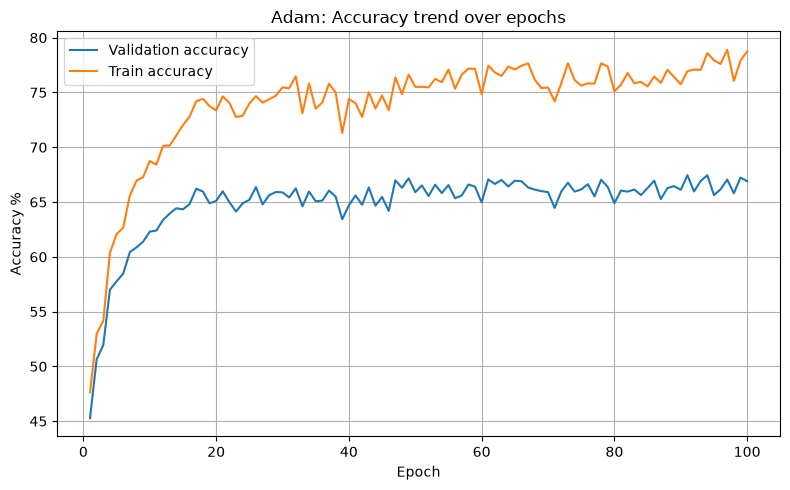

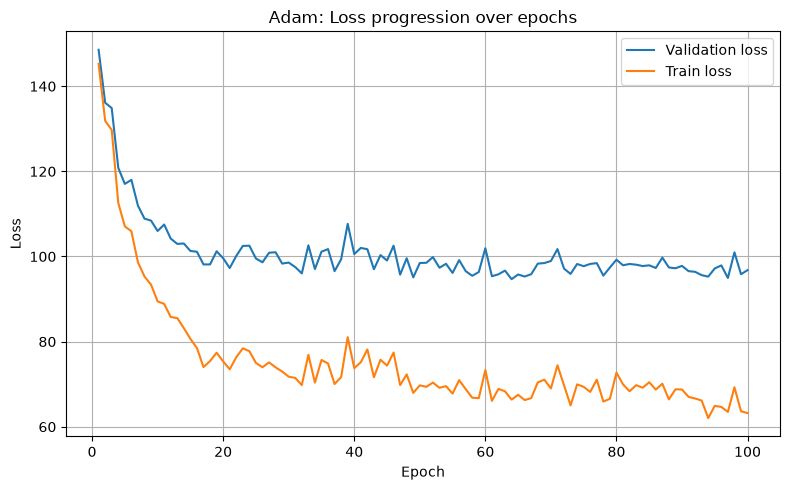

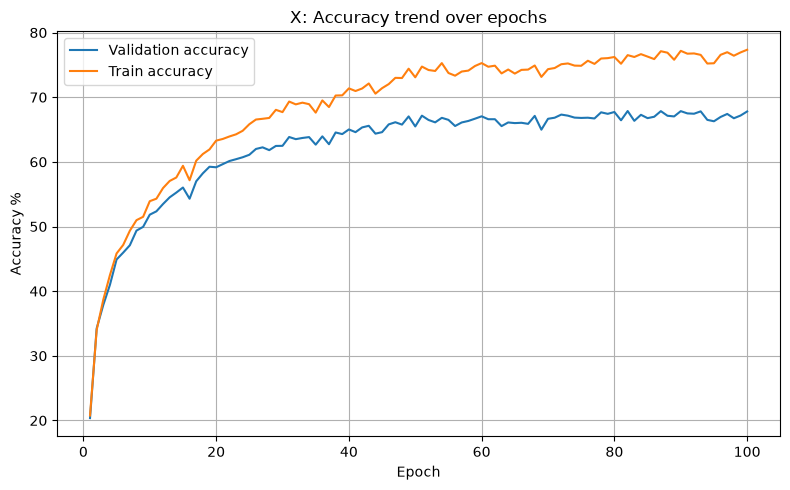

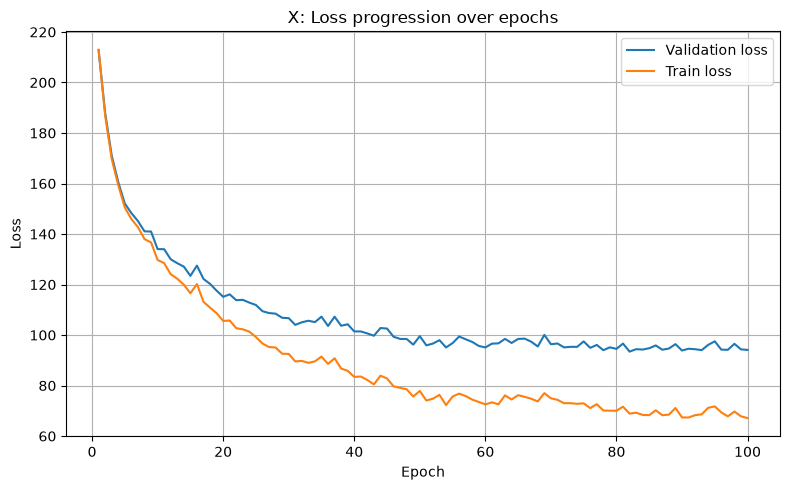

In [16]:
import matplotlib.pyplot as plt

# --- Adam metrics ---
Adam_val_acc = [acc * 100 for (acc, _) in Adam_val_metrics]
Adam_val_loss = [loss * 100 for (_, loss) in Adam_val_metrics]
Adam_train_acc = [acc * 100 for (acc, _) in Adam_train_metrics]
Adam_train_loss = [loss * 100 for (_, loss) in Adam_train_metrics]

# --- Second optimizer metrics (replace X with e.g. SGD) ---
X_val_acc = [acc * 100 for (acc, _) in SGD_val_metrics]
X_val_loss = [loss * 100 for (_, loss) in SGD_val_metrics]
X_train_acc = [acc * 100 for (acc, _) in SGD_train_metrics]
X_train_loss = [loss * 100 for (_, loss) in SGD_train_metrics]

epoch_range = range(1, 101)

# --- Adam: Accuracy ---
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, Adam_val_acc, label='Validation accuracy')
plt.plot(epoch_range, Adam_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Adam: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Adam: Loss ---
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, Adam_val_loss, label='Validation loss')
plt.plot(epoch_range, Adam_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- X: Accuracy ---
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, X_val_acc, label='Validation accuracy')
plt.plot(epoch_range, X_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('X: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- X: Loss ---
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, X_val_loss, label='Validation loss')
plt.plot(epoch_range, X_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('X: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Simulating Non-IID-ness

Real clients will never achieve IID-ness over the dataset, meaning that some sort label-skewness is always present and in order to achieve that we'll perform a Dirichlet-based label-skew partition. 

### FedArtML label-skew protocol

This entails setting up a distribution vector for each of the 10 classes present in our dataset, for our case study we will simulate $K=10$ clients and analyze 4 different concentrations 

$\alpha = 1000,1,0.5, 0.1$

In [34]:
tfd = tfp.distributions

alphas = {
    "1000": [1000.0]*10,
    "1": [1]*10,
    "0.5": [0.5]*10,
    "0.1": [0.1]*10
}

alphas_class_distributions = {}

for key, value in alphas.items():
    dist = tfd.Dirichlet(alphas[key])
    alphas_class_distributions[key] = dist.sample([10])

### Client dataset generation

For each alpha we now have a matrix containing label-skew representations for each of the classes (that is, the distribution percentage of samples for each of the classes amongst all clients). 

We must now assign the corresponding local dataset to each client with said alpha matrix, but first we must split our centralized dataset into label-specific sets.

In [18]:

def split_by_class_subset(dataset):
    labels = dataset.tensors[1]
    class_datasets = [None] * 10
    for c in range(10):
        idx = torch.where(labels == c)[0]
        class_datasets[c] = torch.utils.data.Subset(dataset, idx)
    return class_datasets

train_classes_datasets = split_by_class_subset(train_data)
test_classes_datasets = split_by_class_subset(test_data)
val_classes_datasets = split_by_class_subset(val_data)

Once that is done we can calculate the number of samples corresponding to the percentage for each client and split the set.

In [23]:
def fractions_to_counts(fracs, n):
    raw = [float(f) * n for f in fracs]
    counts = [int(x) for x in raw]  # floor
    remainder = n - sum(counts)

    fractional_parts = sorted(
        range(len(raw)), key=lambda i: raw[i] - int(raw[i]), reverse=True
    )
    for i in fractional_parts[:remainder]:
        counts[i] += 1

    assert sum(counts) == n
    return counts

In [52]:
class_distributions = alphas_class_distributions["1000"]

clients_datasets = {}

for i in range(10):
    clients_datasets[i] = {"train": [], "test":[], "val":[]}
    

for class_index in range(10):

    train_n = len(train_classes_datasets[class_index])
    train_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), train_n)

    test_n = len(test_classes_datasets[class_index])
    test_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), test_n)

    val_n = len(val_classes_datasets[class_index])
    val_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), val_n)

    train_class_subsets = torch.utils.data.dataset.random_split(train_classes_datasets[class_index], train_counts)
    test_class_subsets = torch.utils.data.dataset.random_split(test_classes_datasets[class_index], test_counts)
    val_class_subsets = torch.utils.data.dataset.random_split(val_classes_datasets[class_index], val_counts)
    for client_index in range(10):
        clients_datasets[client_index]["train"].append(train_class_subsets[client_index])
        clients_datasets[client_index]["test"].append(test_class_subsets[client_index])
        clients_datasets[client_index]["val"].append(val_class_subsets[client_index])

for client_index in range(10):
    clients_datasets[client_index]["train"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["train"])
    clients_datasets[client_index]["test"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["test"])
    clients_datasets[client_index]["val"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["val"])


Now we can train each of the client's models using their local datasets

In [53]:
clients_Adam_metrics = {}
clients_SGD_metrics = {}

for client_index in range(10):
    Adam_model = copy.deepcopy(initial_model)
    Adam_optimizer = torch.optim.Adam(Adam_model.parameters())
    client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
    client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)
    clients_Adam_metrics[client_index] = run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=client_train_loader, val_dataloader=client_val_loader)    

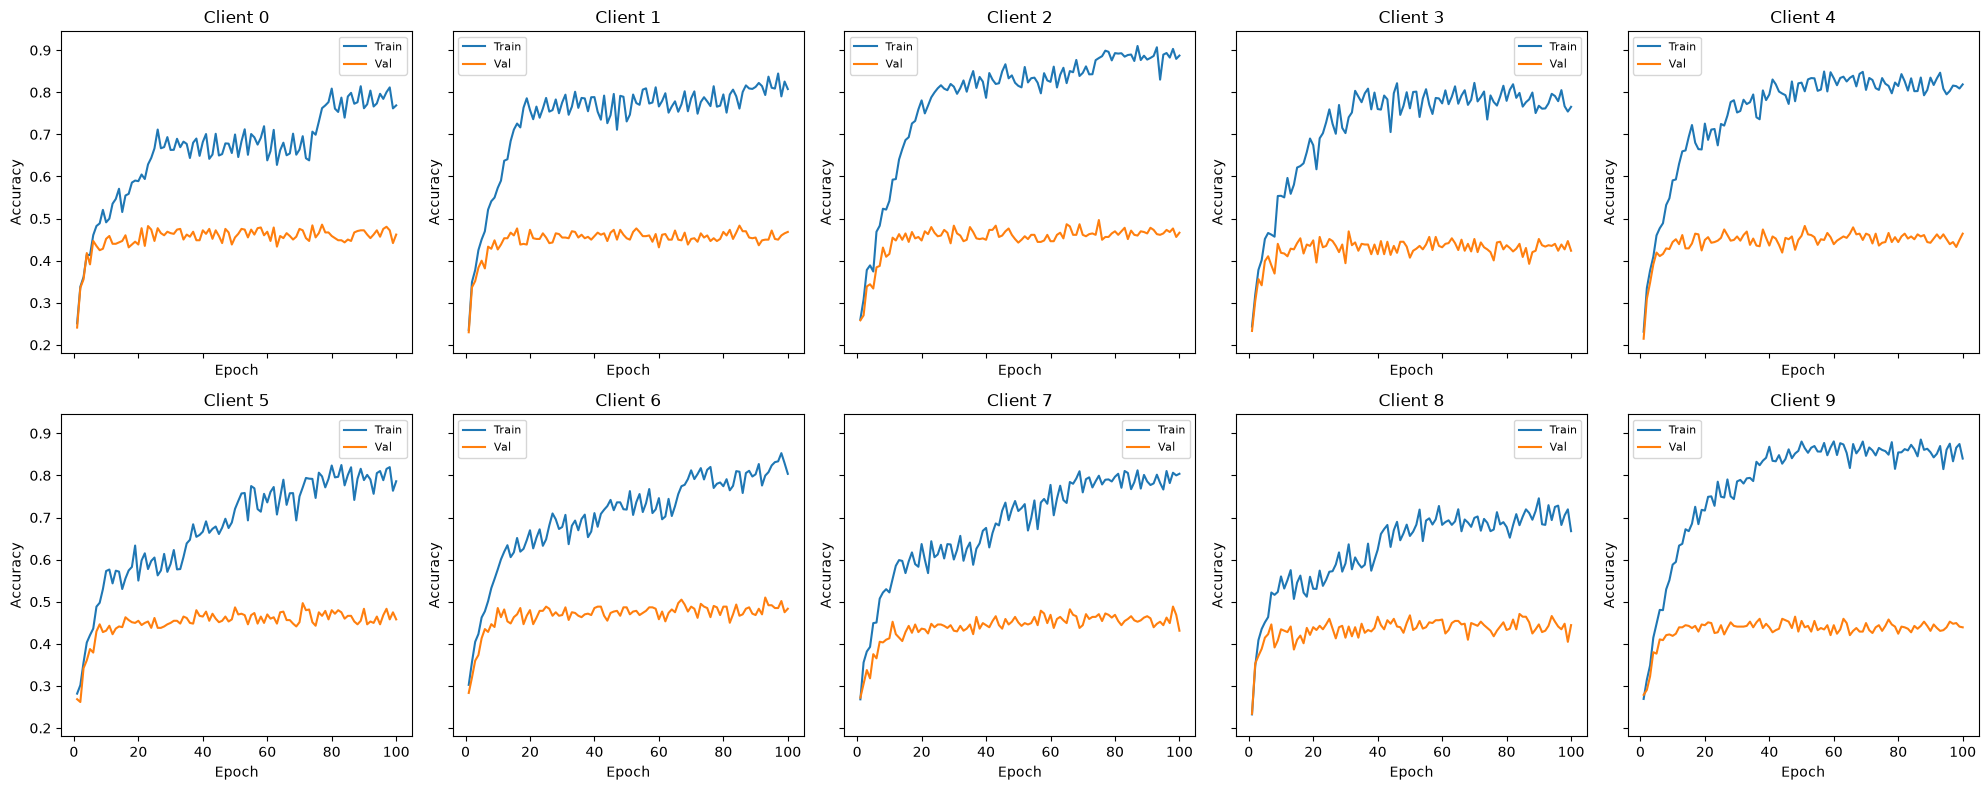

In [58]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for client_index in range(10):
    train_metrics, val_metrics = clients_Adam_metrics[client_index]
    train_acc = [acc for acc, loss in train_metrics]
    val_acc = [acc for acc, loss in val_metrics]
    epochs_range = range(1, len(train_acc) + 1)

    ax = axes[client_index]
    ax.plot(epochs_range, train_acc, label="Train", color="tab:blue")
    ax.plot(epochs_range, val_acc, label="Val", color="tab:orange")
    ax.set_title(f"Client {client_index}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()